# Projeto A3 - Modelagem e comite de classificadores

Nesta etapa, treinaremos e compararemos quatro classificadores:

- KNN (K-Nearest Neighbors)
- Naive Bayes
- SVM (Support Vector Machine)
- Arvore de Decisao

Depois, construiremos um comite por **votacao suave**. Nessa estrategia, a
probabilidade prevista por cada modelo e considerada, e a classe com maior
probabilidade media e escolhida.

## Tecnica: importacao e configuracao das bibliotecas

Este bloco importa os classificadores, as metricas, as ferramentas de
pre-processamento e os recursos de visualizacao. O `RANDOM_STATE` torna
reproduziveis a divisao dos dados e os algoritmos que possuem aleatoriedade.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carregamento e preparacao dos dados

Repetimos a preparacao no notebook para que ele possa ser executado de forma
independente. O mesmo `random_state` garante a mesma divisao da etapa
anterior.

**Tecnicas utilizadas:** limpeza de dados, definicao de features/target e
divisao estratificada. A divisao estratificada preserva a proporcao de churn,
permitindo uma comparacao justa entre os modelos.

In [2]:
possiveis_caminhos = [
    Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]
caminho_dados = next((p for p in possiveis_caminhos if p.exists()), None)
if caminho_dados is None:
    raise FileNotFoundError("Arquivo CSV nao encontrado na pasta data.")

df = pd.read_csv(caminho_dados)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (5634, 19) | Teste: (1409, 19)


**Tecnica utilizada:** pipeline de pre-processamento.

As variaveis numericas recebem imputacao pela mediana e padronizacao. As
categoricas recebem imputacao pela moda e one-hot encoding. O resultado
denso (`sparse_output=False`) e necessario para compatibilidade com o
`GaussianNB`.

In [3]:
colunas_numericas = X.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

pipeline_numerico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="median")),
        ("padronizacao", StandardScaler()),
    ]
)
pipeline_categorico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
preprocessador = ColumnTransformer(
    transformers=[
        ("numerico", pipeline_numerico, colunas_numericas),
        ("categorico", pipeline_categorico, colunas_categoricas),
    ]
)

## 2. Definicao dos classificadores

Os hiperparametros abaixo formam uma configuracao inicial simples:

- KNN utiliza os 11 vizinhos mais proximos.
- Naive Bayes usa a distribuicao gaussiana.
- SVM usa kernel RBF e calibracao para gerar probabilidades para o comite.
- A Arvore tem profundidade limitada para reduzir overfitting.
Todos os modelos sao combinados ao mesmo preprocessador usando `Pipeline`.
**Como cada tecnica funciona:**

- **KNN:** classifica pelo voto dos clientes mais proximos. Depende de
  padronizacao porque calcula distancias;
- **Naive Bayes:** estima probabilidades assumindo independencia entre as
  features. E simples, rapido e costuma apresentar recall elevado;
- **SVM:** procura uma fronteira que separe as classes. O kernel RBF permite
  fronteiras nao lineares, e a calibracao gera probabilidades para o comite;
- **Arvore de Decisao:** cria regras sucessivas e interpretaveis. Limitar a
  profundidade reduz o risco de memorizar os dados de treino;
- **clone:** cria copias independentes do preprocessador para cada modelo.

In [4]:
classificadores = {
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "Naive Bayes": GaussianNB(),
    "SVM": CalibratedClassifierCV(
        SVC(kernel="rbf", random_state=RANDOM_STATE),
        method="sigmoid",
        cv=3,
    ),
    "Arvore de Decisao": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
}

modelos = {
    nome: Pipeline(
        steps=[
            ("preprocessamento", clone(preprocessador)),
            ("classificador", classificador),
        ]
    )
    for nome, classificador in classificadores.items()
}

list(modelos)

['KNN', 'Naive Bayes', 'SVM', 'Arvore de Decisao']

## 3. Treinamento e avaliacao individual

Como o objetivo e identificar clientes que podem cancelar, consideramos
`Churn = Yes` como classe positiva. Avaliaremos:

- **Acuracia:** proporcao total de previsoes corretas.
- **Precisao:** entre os clientes previstos como churn, quantos cancelaram.
- **Recall:** entre os clientes que cancelaram, quantos foram identificados.
- **F1-score:** equilibrio entre precisao e recall.

**Tecnica utilizada:** aprendizado supervisionado.

Cada modelo aprende usando pares de features e respostas conhecidas no
conjunto de treino. Depois, realiza previsoes para clientes do conjunto de
teste. A funcao `calcular_metricas` padroniza a avaliacao de todos os modelos.

In [5]:
def calcular_metricas(y_verdadeiro, y_previsto):
    return {
        "Acuracia": accuracy_score(y_verdadeiro, y_previsto),
        "Precisao": precision_score(y_verdadeiro, y_previsto),
        "Recall": recall_score(y_verdadeiro, y_previsto),
        "F1-score": f1_score(y_verdadeiro, y_previsto),
    }


resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    previsoes[nome] = y_pred
    resultados.append({"Modelo": nome, **calcular_metricas(y_test, y_pred)})

resultados_df = (
    pd.DataFrame(resultados)
    .set_index("Modelo")
    .sort_values("F1-score", ascending=False)
)
print(resultados_df.round(4))

Treinando KNN...


Treinando Naive Bayes...
Treinando SVM...


Treinando Arvore de Decisao...
                   Acuracia  Precisao  Recall  F1-score
Modelo                                                 
Naive Bayes          0.6948    0.4589  0.8369    0.5928
KNN                  0.7779    0.5822  0.5775    0.5799
Arvore de Decisao    0.7970    0.6679  0.4679    0.5503
SVM                  0.7935    0.6627  0.4519    0.5374


## 4. Matrizes de confusao dos modelos individuais

Cada matriz mostra:

- superior esquerdo: clientes sem churn classificados corretamente;
- superior direito: falsos alertas de churn;
- inferior esquerdo: churns nao identificados;
- inferior direito: churns identificados corretamente.

**Tecnica utilizada:** matriz de confusao.

Ela detalha os tipos de acerto e erro. Para retencao de clientes, o quadrante
inferior esquerdo merece atencao, pois representa clientes que cancelaram,
mas foram classificados como se fossem permanecer.

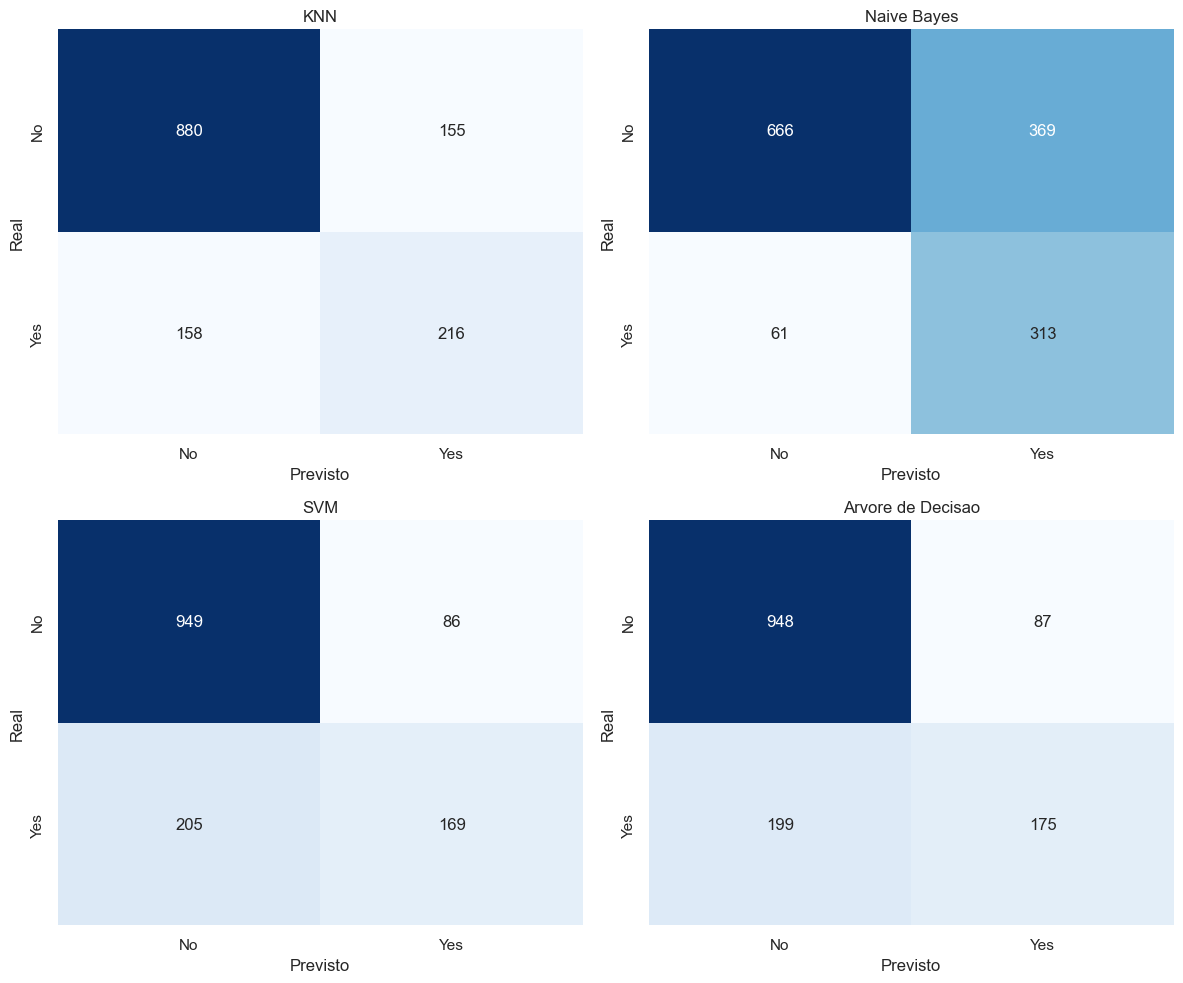

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (nome, y_pred) in zip(axes.flat, previsoes.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"],
    )
    ax.set(title=nome, xlabel="Previsto", ylabel="Real")

plt.tight_layout()
plt.show()

## 5. Construcao do comite

O comite combina os quatro algoritmos por **votacao suave** (`soft voting`).
Cada classificador informa a probabilidade de churn, e o comite calcula a
media dessas probabilidades. Essa estrategia aproveita diferentes formas de
aprendizado e considera o grau de confianca de cada modelo.

**Tecnica utilizada:** ensemble por votacao suave.

Um ensemble combina modelos com comportamentos diferentes para tentar obter
uma decisao mais equilibrada. Diferentemente da votacao majoritaria, a
votacao suave considera a confianca expressa pelas probabilidades.

In [7]:
comite = VotingClassifier(
    estimators=[
        ("knn", clone(modelos["KNN"])),
        ("naive_bayes", clone(modelos["Naive Bayes"])),
        ("svm", clone(modelos["SVM"])),
        ("arvore", clone(modelos["Arvore de Decisao"])),
    ],
    voting="soft",
)

print("Treinando Comite (votacao suave)...")
comite.fit(X_train, y_train)
y_pred_comite = comite.predict(X_test)
previsoes["Comite"] = y_pred_comite

metricas_comite = calcular_metricas(y_test, y_pred_comite)
resultados_df.loc["Comite"] = metricas_comite
resultados_df = resultados_df.sort_values("F1-score", ascending=False)
print(resultados_df.round(4))

Treinando Comite (votacao suave)...


                   Acuracia  Precisao  Recall  F1-score
Modelo                                                 
Comite               0.7743    0.5603  0.6952    0.6205
Naive Bayes          0.6948    0.4589  0.8369    0.5928
KNN                  0.7779    0.5822  0.5775    0.5799
Arvore de Decisao    0.7970    0.6679  0.4679    0.5503
SVM                  0.7935    0.6627  0.4519    0.5374


A matriz abaixo aplica a mesma tecnica de matriz de confusao ao comite. Ela
permite verificar se a combinacao reduziu churns nao identificados sem gerar
uma quantidade excessiva de falsos alertas.

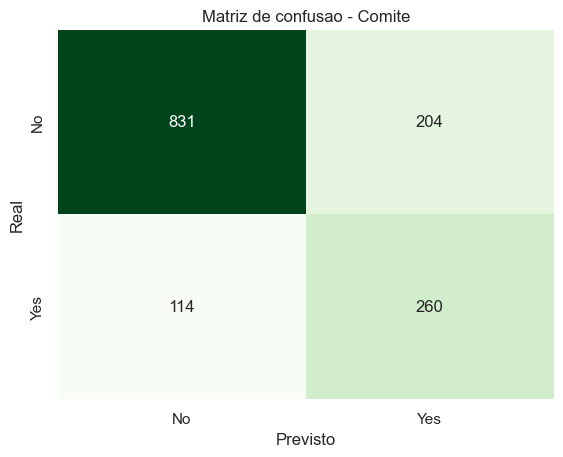

In [8]:
matriz_comite = confusion_matrix(y_test, y_pred_comite)
sns.heatmap(
    matriz_comite,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
plt.title("Matriz de confusao - Comite")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 6. Comparacao final

Como o target e desbalanceado, o F1-score e usado como criterio principal
para comparar o equilibrio entre identificar churns e evitar falsos alertas.

**Tecnica utilizada:** comparacao visual de metricas.

O formato longo criado por `melt` permite colocar as quatro metricas lado a
lado para cada modelo, facilitando a identificacao de seus pontos fortes e
fracos.

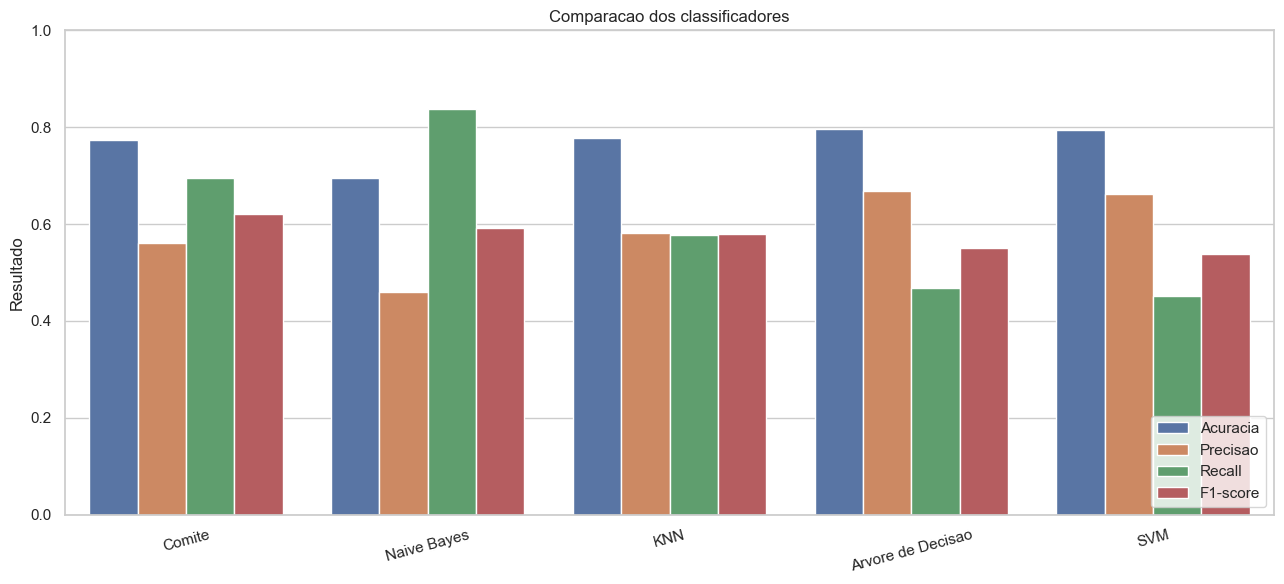

In [9]:
resultados_long = (
    resultados_df.reset_index()
    .melt(id_vars="Modelo", var_name="Metrica", value_name="Valor")
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=resultados_long, x="Modelo", y="Valor", hue="Metrica")
ax.set(title="Comparacao dos classificadores", xlabel="", ylabel="Resultado")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Tecnica utilizada:** selecao do melhor modelo por metrica.

O melhor modelo individual e selecionado pelo maior F1-score e comparado ao
comite. Essa regra responde objetivamente se o ensemble melhorou o equilibrio
entre precisao e recall.

In [10]:
melhor_individual = resultados_df.drop(index="Comite")["F1-score"].idxmax()
melhor_f1_individual = resultados_df.loc[melhor_individual, "F1-score"]
f1_comite = resultados_df.loc["Comite", "F1-score"]

print(f"Melhor modelo individual pelo F1-score: {melhor_individual}")
print(f"F1-score do melhor individual: {melhor_f1_individual:.4f}")
print(f"F1-score do comite: {f1_comite:.4f}")

if f1_comite > melhor_f1_individual:
    print("O comite apresentou melhora sobre o melhor modelo individual.")
else:
    print("O comite nao superou o melhor modelo individual pelo F1-score.")

Melhor modelo individual pelo F1-score: Naive Bayes
F1-score do melhor individual: 0.5928
F1-score do comite: 0.6205
O comite apresentou melhora sobre o melhor modelo individual.


## 7. Predicao de um cliente individual

Ate aqui, o `predict` foi aplicado no conjunto inteiro de teste, com 1.409
clientes. Para demonstrar um caso individual, selecionamos apenas um cliente
usando `iloc[[0]]`.

**Tecnica utilizada:** inferencia para uma unica amostra.

O modelo ja foi treinado. Agora ele recebe os dados de um cliente especifico
e retorna uma previsao:

- `0`: o cliente provavelmente nao cancela;
- `1`: o cliente provavelmente cancela.

Tambem usamos `predict_proba` para mostrar a probabilidade estimada de cada
classe. Isso deixa a decisao mais facil de interpretar.

In [11]:
indice_cliente = 0

cliente_individual = X_test.iloc[[indice_cliente]]
valor_real = y_test.iloc[indice_cliente]

previsao_cliente = comite.predict(cliente_individual)[0]
probabilidades_cliente = comite.predict_proba(cliente_individual)[0]

rotulos = {0: "Nao cancela", 1: "Cancela"}

print("Dados principais do cliente analisado:")
display(
    cliente_individual[
        [
            "tenure",
            "Contract",
            "PaymentMethod",
            "MonthlyCharges",
            "TotalCharges",
            "InternetService",
        ]
    ]
)

print(f"Valor real: {rotulos[valor_real]}")
print(f"Previsao do comite: {rotulos[previsao_cliente]}")
print(f"Probabilidade de nao cancelar: {probabilidades_cliente[0]:.2%}")
print(f"Probabilidade de cancelar: {probabilidades_cliente[1]:.2%}")

Dados principais do cliente analisado:


,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,InternetService
437,72,Two year,Credit card (automatic),114.05,8468.2,Fiber optic


Valor real: Nao cancela
Previsao do comite: Nao cancela
Probabilidade de nao cancelar: 96.76%
Probabilidade de cancelar: 3.24%


Nesse exemplo, mostramos a aplicacao pratica do modelo para um unico cliente.
Em um sistema real, a empresa poderia usar essa previsao para decidir se deve
fazer uma acao de retencao, como oferecer desconto, suporte ou contato
preventivo.

## Conclusao da etapa

Os quatro classificadores individuais e o comite foram treinados e avaliados
no mesmo conjunto de teste. O fato de um comite nao necessariamente superar
o melhor modelo individual e um resultado valido: seu desempenho depende da
diversidade e da qualidade dos classificadores que o compoem.

Na proxima etapa, os resultados serao interpretados em detalhes e usados na
elaboracao do relatorio final.